# Train a simple intrusion-detection model

This notebook walks through a beginner-friendly training workflow for the CSE-CIC-IDS2018 dataset.

The goal is to train a simple classifier for network intrusion detection, while keeping the logic reusable for a production prediction agent.

## 1. Import required libraries and configure the project

The next cell sets up the project paths, random seed, and the mode you want to train.

- Use `binary` for BENIGN vs MALICIOUS.
- Use `multiclass` for BENIGN plus attack categories.

In [12]:
import json
import sys
from pathlib import Path
from tkinter import NONE

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

PROJECT_ROOT = Path.cwd().resolve()
if (PROJECT_ROOT / "src").exists():
    pass
elif (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
else:
    PROJECT_ROOT = PROJECT_ROOT

sys.path.insert(0, str(PROJECT_ROOT / "src"))

from data_loader import discover_csv_files, load_csv_files
from export_model import build_evaluation_payload, build_model_metadata, export_artifacts, load_artifacts
from preprocessing import (
    build_binary_labels,
    build_preprocessor,
    clean_column_names,
    detect_label_column,
    prepare_feature_frame,
    prepare_single_record,
    select_feature_columns,
    split_train_test,
)

RANDOM_SEED = 42
MODE = "binary" 
TEST_SIZE = 0.2
MAX_ROWS = None
SCALING_REQUIRED = True
DATA_DIR = PROJECT_ROOT / "data"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
DATASET_NAME = "CSE-CIC-IDS2018"
BENIGN_LABEL = "Benign"
METADATA_COLUMNS = ["Flow ID", "Source IP", "Destination IP", "Timestamp"]

sns.set_theme(style="whitegrid")

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\bryan\Network_Monitoring_App\model-training


## 2. Discover and load multiple CSV files

The dataset is split into several CSV files. This step finds those files and loads them into a single dataframe.

In [13]:
csv_files = discover_csv_files(DATA_DIR)
print(f"Found {len(csv_files)} CSV files")
for file_path in csv_files:
    print(file_path.name)

raw_df = load_csv_files(csv_files)
if MAX_ROWS and len(raw_df) > MAX_ROWS:
    raw_df = raw_df.sample(n=MAX_ROWS, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Loaded shape: {raw_df.shape}")
raw_df.head()

Found 14 CSV files
Bot.csv
Brute Force -Web.csv
Brute Force -XSS.csv
DDOS attack-HOIC.csv
DDOS attack-LOIC-UDP.csv
DDoS attacks-LOIC-HTTP.csv
DoS attacks-GoldenEye.csv
DoS attacks-Hulk.csv
DoS attacks-SlowHTTPTest.csv
DoS attacks-Slowloris.csv
FTP-BruteForce.csv
Infilteration.csv
SQL Injection.csv
SSH-Bruteforce.csv
Loaded shape: (9625148, 79)


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,6,257024,11,11,1249,1969.0,736,0,113.545455,...,20,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign
1,0,0,112641101,3,0,0,0.0,0,0,0.000000,...,0,0.0,0.0,0.0,0.0,56300000.0,84.145707,56300000.0,56300000.0,Benign
2,0,0,112639047,3,0,0,0.0,0,0,0.000000,...,0,0.0,0.0,0.0,0.0,56300000.0,96.873629,56300000.0,56300000.0,Benign
3,0,0,112640744,3,0,0,0.0,0,0,0.000000,...,0,0.0,0.0,0.0,0.0,56300000.0,7.071068,56300000.0,56300000.0,Benign
4,22,6,5707641,14,11,1123,1969.0,648,0,80.214286,...,32,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,Benign


## 3. Inspect the data

This step shows file names, row counts, column names, data types, missing values, and the label distribution.

In [14]:
file_overview = []
for path in csv_files:
    frame = pd.read_csv(path, low_memory=False)
    file_overview.append({
        "file": path.name,
        "rows": len(frame),
        "columns": len(frame.columns),
        "sample_columns": ", ".join(list(frame.columns[:8]))
    })

for path in csv_files:
    frame=pd.read_csv(path,low_memory=False)

overview_df = pd.DataFrame(file_overview)
overview_df

,file,rows,columns,sample_columns
0,Bot.csv,1017903,79,"Dst Port, Protocol, Flow Duration, Tot Fwd Pkt..."
1,Brute Force -Web.csv,2073,79,"Dst Port, Protocol, Flow Duration, Tot Fwd Pkt..."
2,Brute Force -XSS.csv,734,79,"Dst Port, Protocol, Flow Duration, Tot Fwd Pkt..."
3,DDOS attack-HOIC.csv,2332000,79,"Dst Port, Protocol, Flow Duration, Tot Fwd Pkt..."
4,DDOS attack-LOIC-UDP.csv,5784,79,"Dst Port, Protocol, Flow Duration, Tot Fwd Pkt..."
5,DDoS attacks-LOIC-HTTP.csv,2222355,79,"Dst Port, Protocol, Flow Duration, Tot Fwd Pkt..."
6,DoS attacks-GoldenEye.csv,139922,79,"Dst Port, Protocol, Flow Duration, Tot Fwd Pkt..."
7,DoS attacks-Hulk.csv,1559854,79,"Dst Port, Protocol, Flow Duration, Tot Fwd Pkt..."
8,DoS attacks-SlowHTTPTest.csv,469631,79,"Dst Port, Protocol, Flow Duration, Tot Fwd Pkt..."
9,DoS attacks-Slowloris.csv,36754,79,"Dst Port, Protocol, Flow Duration, Tot Fwd Pkt..."


In [15]:
# Basic dataframe inspection
df = clean_column_names(raw_df)
print("Columns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes.astype(str).to_string())
print("\nMissing values:")
print(df.isna().sum().sort_values(ascending=False).head(20).to_string())

label_column = detect_label_column(df)
print(f"\nDetected label column: {label_column}")
print("\nLabel distribution:")
print(df[label_column].value_counts(dropna=False).head(15).to_string())

Columns:
['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b

## 4. Clean the data and prepare model features

The next cells remove metadata columns, strip whitespace from column names, convert values to numeric, replace infinity with missing values, and remove exact duplicate rows.

In [16]:
# Remove exact duplicates after cleaning the dataframe
before_drop = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after_drop = len(df)
print(f"Removed {before_drop - after_drop} duplicate rows")

# Keep the label column visible for the training workflow
feature_columns = select_feature_columns(df, label_column, metadata_columns=METADATA_COLUMNS)
print(f"Selected {len(feature_columns)} feature columns")

feature_frame = prepare_feature_frame(df, feature_columns, metadata_columns=METADATA_COLUMNS)
print(feature_frame.head())
print(f"Prepared shape: {feature_frame.shape}")

Removed 4442127 duplicate rows
Selected 78 feature columns
   Dst Port  Protocol  Flow Duration  Tot Fwd Pkts  Tot Bwd Pkts  \
0        22         6         257024            11            11   
1         0         0      112641101             3             0   
2         0         0      112639047             3             0   
3         0         0      112640744             3             0   
4        22         6        5707641            14            11   

   TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  Fwd Pkt Len Min  \
0             1249           1969.0              736                0   
1                0              0.0                0                0   
2                0              0.0                0                0   
3                0              0.0                0                0   
4             1123           1969.0              648                0   

   Fwd Pkt Len Mean  ...  Fwd Act Data Pkts  Fwd Seg Size Min  Active Mean  \
0        113.54

## 5. Why accuracy alone is not enough

Intrusion-detection datasets are often highly imbalanced. A model may achieve high accuracy by predicting the majority class most of the time, while failing to detect attacks.

For that reason, this notebook reports balanced accuracy, precision, recall, F1, and a confusion matrix in addition to raw accuracy.

Target distribution:
binary_label
BENIGN       3830384
MALICIOUS    1352637


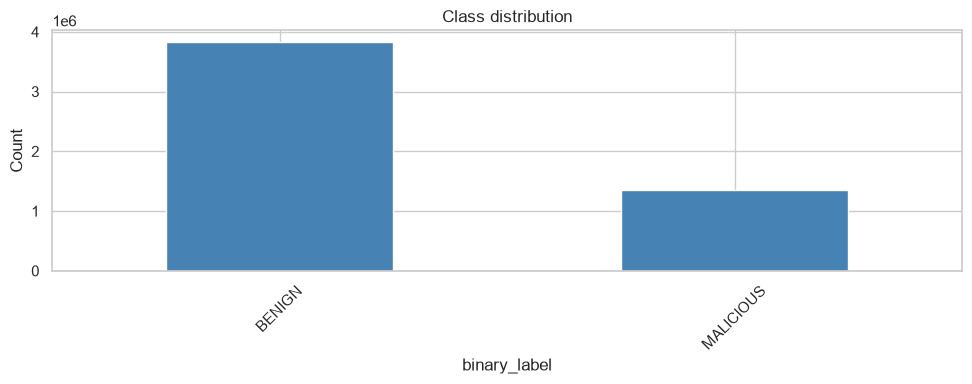

In [17]:
# Create a binary target when requested
raw_labels = df[label_column].astype(str).str.strip()
if MODE == "binary":
    target = build_binary_labels(raw_labels, benign_label=BENIGN_LABEL)
    target_name = "binary_label"
else:
    target = raw_labels
    target_name = label_column

print("Target distribution:")
print(pd.Series(target).value_counts().to_string())

# Visualize class imbalance clearly
plt.figure(figsize=(10, 4))
pd.Series(target).value_counts().plot(kind="bar", color="steelblue")
plt.title("Class distribution")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. Split the data without leakage

The preprocessing is fit only on the training split. This avoids data leakage and makes the evaluation more realistic.

In [18]:
# Encode labels for model training
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(target)

X_train_df, X_test_df, y_train, y_test = split_train_test(
    feature_frame,
    pd.Series(y, index=feature_frame.index),
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=True,
)

print(f"Training rows: {len(X_train_df)}")
print(f"Test rows: {len(X_test_df)}")
print(f"Training class distribution: {pd.Series(y_train).value_counts().to_dict()}")
print(f"Test class distribution: {pd.Series(y_test).value_counts().to_dict()}")

Training rows: 4146416
Test rows: 1036605
Training class distribution: {0: 3064307, 1: 1082109}
Test class distribution: {0: 766077, 1: 270528}


In [19]:
# Fit preprocessing only on the training split
preprocessor = build_preprocessor(scaling_required=SCALING_REQUIRED)
X_train_processed = preprocessor.fit_transform(X_train_df)
X_test_processed = preprocessor.transform(X_test_df)

print(f"Processed training shape: {X_train_processed.shape}")
print(f"Processed test shape: {X_test_processed.shape}")

Processed training shape: (4146416, 78)
Processed test shape: (1036605, 78)


## 7. Train a baseline model and a random forest model

The baseline is a simple decision tree. The second model is a RandomForestClassifier, which usually performs better on tabular data.

In [20]:
def plot_model_evaluation(
    y_true,
    y_pred,
    label_encoder,
    model_name: str,
):

    class_names = [str(name) for name in label_encoder.classes_]

    overall_metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Macro recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "Weighted F1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
    }

    report = classification_report(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
    )

    figure, axis = plt.subplots(figsize=(7, 6))

    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=class_names,
    )

    display.plot(
        ax=axis,
        values_format=",d",
        colorbar=False,
    )

    axis.set_title(f"{model_name} — Confusion Matrix")
    axis.set_xlabel("Predicted label")
    axis.set_ylabel("Actual label")

    plt.tight_layout()
    plt.show()

    normalized_matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
        normalize="true",
    )

    figure, axis = plt.subplots(figsize=(7, 6))

    display = ConfusionMatrixDisplay(
        confusion_matrix=normalized_matrix,
        display_labels=class_names,
    )

    display.plot(
        ax=axis,
        values_format=".2%",
        colorbar=False,
    )

    axis.set_title(f"{model_name} — Normalized Confusion Matrix")
    axis.set_xlabel("Predicted label")
    axis.set_ylabel("Actual label")

    plt.tight_layout()
    plt.show()

    metric_names = list(overall_metrics.keys())
    metric_values = list(overall_metrics.values())

    figure, axis = plt.subplots(figsize=(10, 5))

    bars = axis.bar(metric_names, metric_values)

    axis.set_title(f"{model_name} — Overall Metrics")
    axis.set_ylabel("Score")
    axis.set_ylim(0, 1.05)
    axis.tick_params(axis="x", rotation=30)

    for bar, value in zip(bars, metric_values):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.01,
            f"{value:.3f}",
            ha="center",
            va="bottom",
        )

    plt.tight_layout()
    plt.show()

    precision_values = [
        report[class_name]["precision"]
        for class_name in class_names
    ]
    recall_values = [
        report[class_name]["recall"]
        for class_name in class_names
    ]
    f1_values = [
        report[class_name]["f1-score"]
        for class_name in class_names
    ]

    positions = np.arange(len(class_names))
    width = 0.25

    figure, axis = plt.subplots(figsize=(10, 6))

    precision_bars = axis.bar(
        positions - width,
        precision_values,
        width,
        label="Precision",
    )

    recall_bars = axis.bar(
        positions,
        recall_values,
        width,
        label="Recall",
    )

    f1_bars = axis.bar(
        positions + width,
        f1_values,
        width,
        label="F1",
    )

    axis.set_title(f"{model_name} — Per-Class Metrics")
    axis.set_ylabel("Score")
    axis.set_ylim(0, 1.05)
    axis.set_xticks(positions)
    axis.set_xticklabels(class_names)
    axis.legend()

    for bars in (precision_bars, recall_bars, f1_bars):
        for bar in bars:
            value = bar.get_height()
            axis.text(
                bar.get_x() + bar.get_width() / 2,
                value + 0.01,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

    plt.tight_layout()
    plt.show()

    return {
        "overall_metrics": overall_metrics,
        "classification_report": report,
        "confusion_matrix": matrix.tolist(),
        "class_names": class_names,
    }

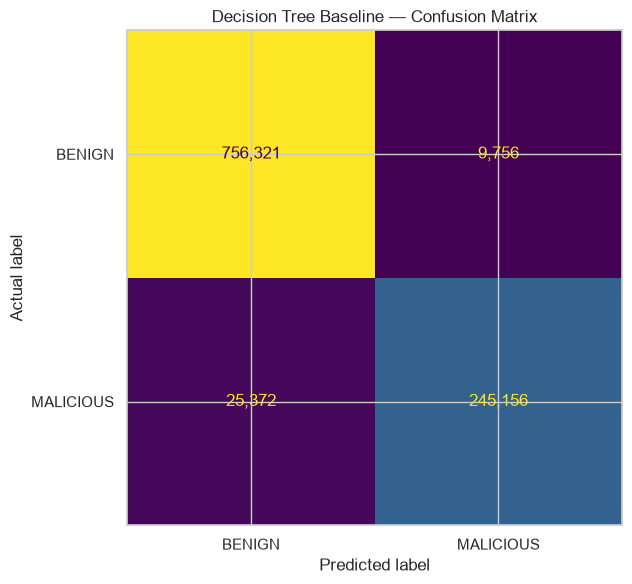

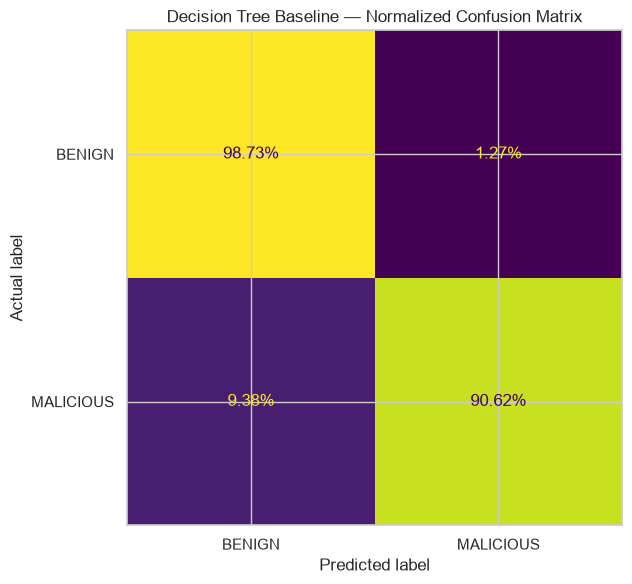

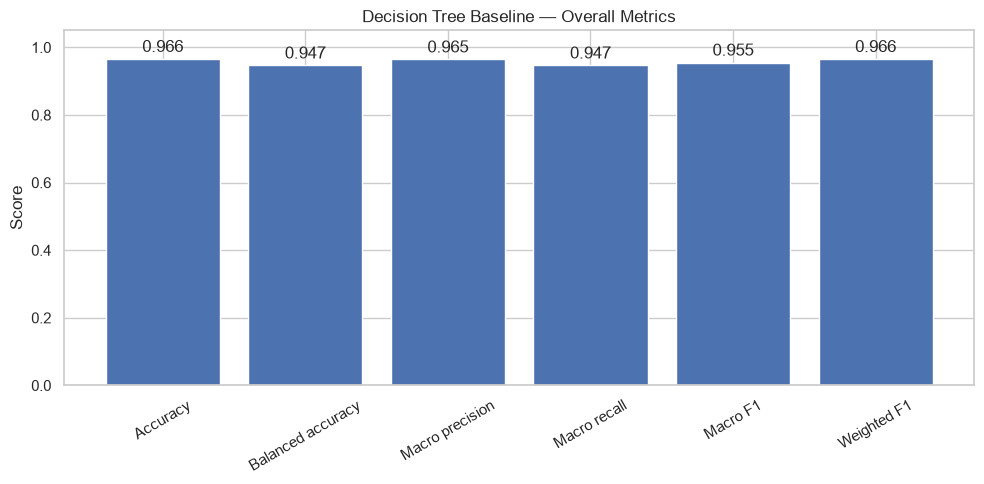

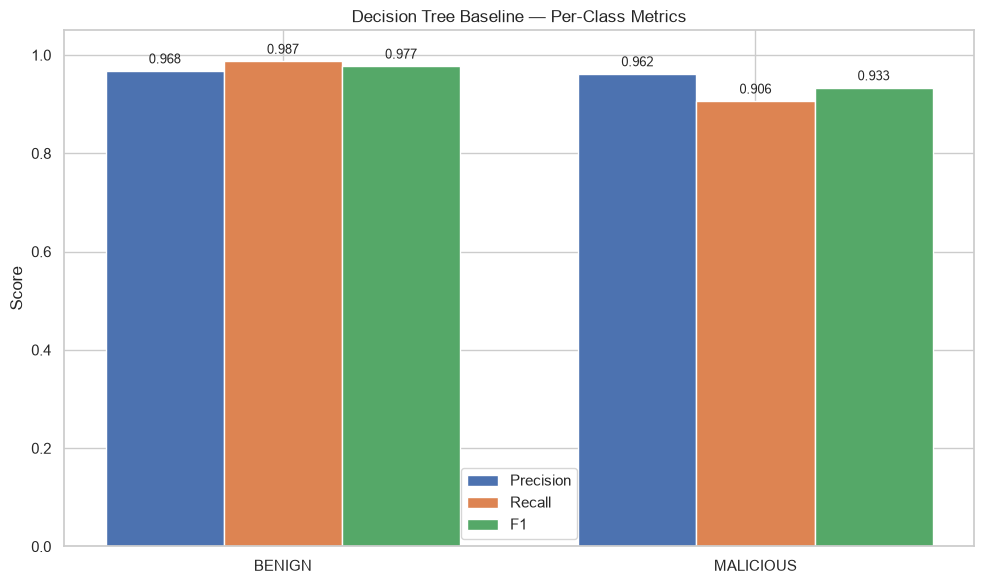

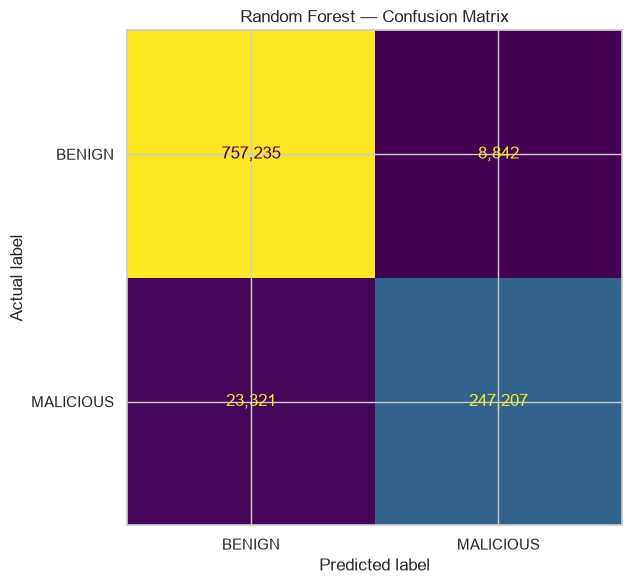

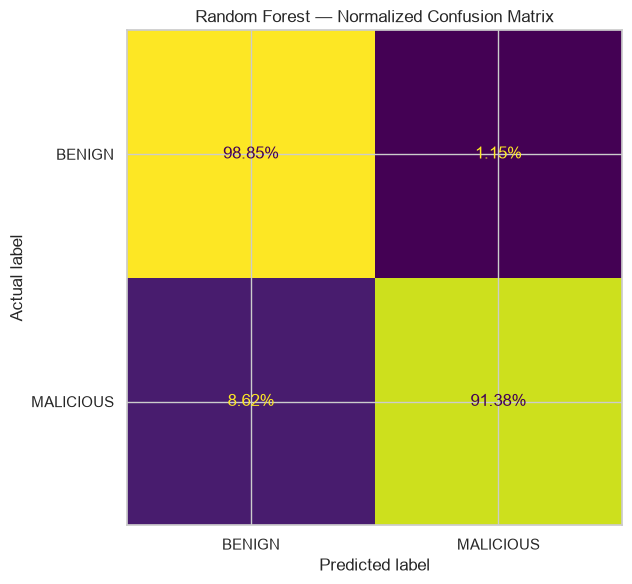

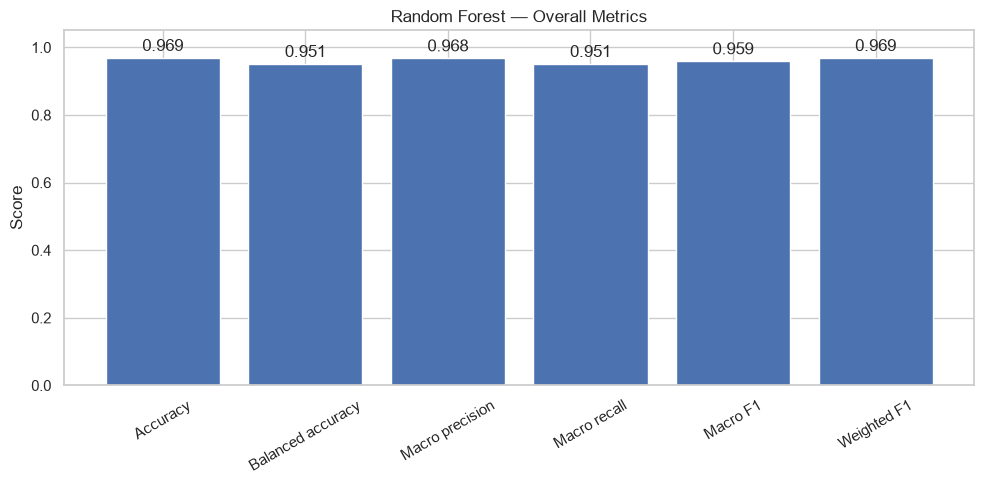

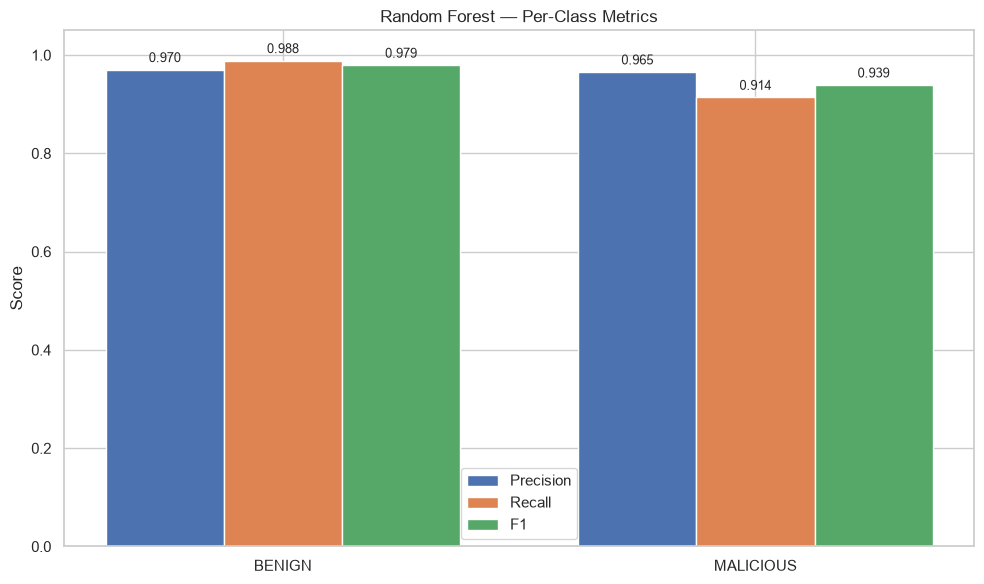

In [21]:
baseline_model = DecisionTreeClassifier(
    max_depth=8,
    random_state=RANDOM_SEED,
)

baseline_model.fit(X_train_processed, y_train)
baseline_pred = baseline_model.predict(X_test_processed)

baseline_eval = plot_model_evaluation(
    y_true=y_test,
    y_pred=baseline_pred,
    label_encoder=label_encoder,
    model_name="Decision Tree Baseline",
)


rf_model = RandomForestClassifier(
    n_estimators=120,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight="balanced_subsample",
)

rf_model.fit(X_train_processed, y_train)
rf_pred = rf_model.predict(X_test_processed)

rf_eval = plot_model_evaluation(
    y_true=y_test,
    y_pred=rf_pred,
    label_encoder=label_encoder,
    model_name="Random Forest",
)


selected_model = rf_model
selected_eval = rf_eval

## 8. Save the trained model and supporting artifacts

The artifacts in the artifacts folder are intended for the production prediction agent.

The notebook saves the model, preprocessing object, feature order, label encoder, metadata, and evaluation metrics.

In [22]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

metadata = build_model_metadata(
    model_name="CSE-CIC-IDS2018 Binary Random Forest",
    dataset_name=DATASET_NAME,
    mode=MODE,
    model_class=selected_model.__class__.__name__,
    target_labels=sorted(label_encoder.classes_.tolist()),
    benign_label=BENIGN_LABEL,
    feature_count=len(feature_columns),
    missing_value_policy="Convert all values to numeric and replace infinities with NaN; impute missing values with median.",
    infinity_policy="Replace positive and negative infinity with NaN before model training.",
    scaling_required=SCALING_REQUIRED,
    train_test_split={"test_size": TEST_SIZE, "random_state": RANDOM_SEED, "stratify": True},
    random_seed=RANDOM_SEED,
    metrics=selected_eval,
)

export_artifacts(
    ARTIFACT_DIR,
    model=selected_model,
    preprocessor=preprocessor,
    feature_columns=feature_columns,
    label_encoder=label_encoder,
    metadata=metadata,
    evaluation=selected_eval,
)

print("Artifacts exported to:")
for artifact in [ARTIFACT_DIR / "model.pkl", ARTIFACT_DIR / "scaler.pkl", ARTIFACT_DIR / "feature_columns.json", ARTIFACT_DIR / "label_encoder.pkl", ARTIFACT_DIR / "model_metadata.json", ARTIFACT_DIR / "evaluation.json"]:
    print(artifact.name)

Artifacts exported to:
model.pkl
scaler.pkl
feature_columns.json
label_encoder.pkl
model_metadata.json
evaluation.json


## 9. Reload artifacts from disk and predict on held-out rows

This final section verifies that the exported artifacts work independently of the notebook variables.

In [23]:
reloaded = load_artifacts(ARTIFACT_DIR)
model_from_disk = reloaded["model"]
preprocessor_from_disk = reloaded["preprocessor"]
loaded_feature_columns = reloaded["feature_columns"]
loaded_label_encoder = reloaded["label_encoder"]

# Use a few rows from the held-out test split
sample_rows = X_test_df.head(3).to_dict(orient="records")
print("Predictions from reloaded artifacts:")
for row in sample_rows:
    prepared_row = prepare_single_record(
        row,
        loaded_feature_columns,
        metadata_columns=METADATA_COLUMNS,
        preprocessor=preprocessor_from_disk,
    )
    prediction = model_from_disk.predict(prepared_row)
    print(f"Predicted: {loaded_label_encoder.inverse_transform(prediction)[0]}")

Predictions from reloaded artifacts:
Predicted: BENIGN
Predicted: MALICIOUS
Predicted: BENIGN


In [ ]:
from pathlib import Path

SAMPLE_SIZE = 20

sample_csv_df = X_test_df.sample(
    n=min(SAMPLE_SIZE, len(X_test_df)),
    random_state=RANDOM_SEED,
).copy()

sample_csv_df = sample_csv_df.loc[:, feature_columns]

sample_csv_path = ARTIFACT_DIR / "sample_model_input.csv"
sample_csv_df.to_csv(sample_csv_path, index=False)

print(f"Sample CSV created: {sample_csv_path.resolve()}")
print(f"Rows: {len(sample_csv_df)}")
print(f"Columns: {len(sample_csv_df.columns)}")

display(sample_csv_df.head())

Sample CSV created: C:\Users\bryan\Network_Monitoring_App\model-training\artifacts\sample_model_input.csv
Rows: 20
Columns: 78


,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
4841600,53,17,473,1,1,36,52.0,36,36,36.000000,...,0,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4779213,7402,6,365,1,1,0,0.0,0,0,0.000000,...,0,24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4511366,80,6,91417711,11162,21615,5466,31463023.0,330,0,0.489697,...,17,20,22840202.0,0.0,22840202.0,22840202.0,68577509.0,0.0,68577509.0,68577509.0
2188358,53,17,40160,1,1,37,102.0,37,37,37.000000,...,0,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3112041,60221,6,42,2,0,0,0.0,0,0,0.000000,...,0,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [32]:
import pandas as pd
reloaded_model = load_artifacts(ARTIFACT_DIR)
test_model=reloaded_model["model"]
test_preprocessor=reloaded_model["preprocessor"]
loaded_feature_columns = reloaded_model["feature_columns"]
loaded_label_encoder=reloaded_model["label_encoder"]

sample_csv_path=ARTIFACT_DIR / "sample_model_input.csv"
test_df=pd.read_csv(sample_csv_path)

print(test_df.head())

   Dst Port  Protocol  Flow Duration  Tot Fwd Pkts  Tot Bwd Pkts  \
0        53        17            473             1             1   
1      7402         6            365             1             1   
2        80         6       91417711         11162         21615   
3        53        17          40160             1             1   
4     60221         6             42             2             0   

   TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  Fwd Pkt Len Min  \
0               36             52.0               36               36   
1                0              0.0                0                0   
2             5466       31463023.0              330                0   
3               37            102.0               37               37   
4                0              0.0                0                0   

   Fwd Pkt Len Mean  ...  Fwd Act Data Pkts  Fwd Seg Size Min  Active Mean  \
0         36.000000  ...                  0                 8          0.0

In [ ]:
test_input=prepare_feature_frame(test_df,loaded_feature_columns,metadata_columns=METADATA_COLUMNS)
test_input=test_preprocessor.transform(test_input)
prediction=test_model.predict(test_input)

prediction_labels=loaded_label_encoder.inverse_transform(prediction)

print("Predictions for sample input:")
k=0
for i, label in enumerate(prediction_labels):
    if label != BENIGN_LABEL:
        malicious_row = test_df.iloc[i]
        print(f"Alert: Row {malicious_row} predicted as malicious traffic ({label})")
        k+=1

print(f"Total malicious predictions: {k} out of {len(prediction_labels)} rows")


Predictions for sample input:
Alert: Row Dst Port          53.0
Protocol          17.0
Flow Duration    473.0
Tot Fwd Pkts       1.0
Tot Bwd Pkts       1.0
                 ...  
Active Min         0.0
Idle Mean          0.0
Idle Std           0.0
Idle Max           0.0
Idle Min           0.0
Name: 0, Length: 78, dtype: float64 predicted as malicious traffic (BENIGN)
Alert: Row Dst Port         7402.0
Protocol            6.0
Flow Duration     365.0
Tot Fwd Pkts        1.0
Tot Bwd Pkts        1.0
                  ...  
Active Min          0.0
Idle Mean           0.0
Idle Std            0.0
Idle Max            0.0
Idle Min            0.0
Name: 1, Length: 78, dtype: float64 predicted as malicious traffic (MALICIOUS)
Alert: Row Dst Port               80.0
Protocol                6.0
Flow Duration    91417711.0
Tot Fwd Pkts        11162.0
Tot Bwd Pkts        21615.0
                    ...    
Active Min       22840202.0
Idle Mean        68577509.0
Idle Std                0.0
Idle Max     